# 1.  Variogram Modeling 



**Dataset:** Jura geochemical survey (`data/jura_data.csv`)  

**Library:** `pygstat` v0.1.0  



***

## Table of Contents

1. [Overview](#1-overview)
2. [What is a Variogram?](#2-what-is-a-variogram)
   - 2.1 [Key Parameters](#21-key-parameters)
   - 2.2 [How the Variogram Works](#22-how-the-variogram-works)
3. [Types of Variograms](#3-types-of-variograms)
   - 3.1 [Theoretical Model Functions](#31-theoretical-model-functions)
   - 3.2 [Isotropic vs Anisotropic](#32-isotropic-vs-anisotropic)
4. [Python Setup](#4-python-setup)
   - 4.1 [CPU and GPU](#41-cpu-and-gpu)
5. [Load and Explore the Jura Dataset](#5-load-and-explore-the-jura-dataset)
6. [CPU vs GPU Timing](#6-cpu-vs-gpu-timing)
7. [Empirical Variogram — Robust Estimators](#7-empirical-variogram---robust-estimators)
   - 7.1 [Matheron Estimator](#71-matheron-estimator)
   - 7.2 [Cressie–Hawkins Estimator](#72-cressie–hawkins-estimator)
   - 7.3 [Dowd Estimator](#73-dowd-estimator)
   - 7.4 [Estimator Comparison](#74-estimator-comparison)
8. [Isotropic Variogram Modeling](#8-isotropic-variogram-modeling)
   - 8.1 [Spherical Model](#81-spherical-model)
   - 8.2 [Exponential Model](#82-exponential-model)
   - 8.3 [Gaussian Model](#83-gaussian-model)
   - 8.4 [Matérn Model](#84-matérn-model)
   - 8.5 [Stable Model](#85-stable-model)
   - 8.6 [Cubic Model](#86-cubic-model)
   - 8.7 [All Models Compared](#87-all-models-compared)
9. [Anisotropic Variogram Modeling](#9-anisotropic-variogram-modeling)
10. [Best-Fitting Model Selection](#10-best-fitting-model-selection)
11. [Summary and Conclusions](#11-summary-and-conclusions)
12. [Resources](#12-resources)


***
## 1. Overview

Geostatistics is the branch of spatial statistics that studies **spatially correlated** phenomena. At its heart lies the **variogram** (or **semivariogram**), a function that quantifies how spatial correlation decays with distance. Before any spatial prediction (kriging, simulation) can be performed, a variogram must be computed from data and a theoretical model must be fitted to it.

This tutorial covers the full variogram-modeling workflow using **PyGStat** and the classic **Jura geochemical dataset**. The same cells run on **CPU** (NumPy) or **GPU** (CuPy): a one-time kernel probe sets `USE_GPU`, and every `Variogram` call below passes `use_gpu=USE_GPU`.

| Step | What we do |
|------|------------|
| Empirical estimation | Compute the experimental variogram using Matheron, Cressie–Hawkins, and Dowd estimators |
| Model fitting | Fit spherical, exponential, gaussian, Matérn, stable, and cubic theoretical models |
| Anisotropy | Detect and model directional dependence |
| Model selection | Rank models by residual sum of squares and AIC |
| CPU / GPU | Auto-detect a usable CuPy GPU; fall back to CPU when the card cannot run a kernel |

By the end, you will have a production-ready variogram model ready for kriging interpolation.


***
## 2. What is a Variogram?

The **semivariogram** (commonly called the variogram) measures the average squared difference between pairs of observations separated by a lag distance $h$:

$$
\gamma(h) = \frac{1}{2} \mathbb{E}\left[ Z(\mathbf{x}) - Z(\mathbf{x}+\mathbf{h}) \right]^2
$$

where $Z(\mathbf{x})$ is the random field at location $\mathbf{x}$ and $\mathbf{h}$ is the separation vector.

Under the **intrinsic stationarity** assumption, $\gamma(h)$ depends only on the lag vector $\mathbf{h}$, not on the absolute position $\mathbf{x}$.



### 2.1 Key Parameters

| Parameter | Symbol | Description |
|-----------|--------|-------------|
| **Nugget** | $C_0$ | Variance at lag = 0; represents micro-scale variation and measurement error |
| **Sill** | $C_0 + C$ | Total variance; the variogram asymptote |
| **Range** | $a$ | Lag distance at which the variogram reaches the sill; beyond this, observations are uncorrelated |
| **Partial sill** | $C$ | Structurally explained variance: sill − nugget |

```



![Variogram](../Image/variogram.png)



### 2.2 How the Variogram Works

1. **Pair all observations** and compute their separation distance $h_{ij} = \|\mathbf{x}_i - \mathbf{x}_j\|$.
2. **Bin pairs** into lag classes $[h_k, h_{k+1})$.
3. **Apply an estimator** within each bin to get the experimental variogram value $\hat{\gamma}(h_k)$.
4. **Fit a theoretical model** $\gamma(h; \boldsymbol{\theta})$ to the experimental cloud by weighted least squares.
5. Use the fitted model in **kriging** to interpolate at unsampled locations.

***
## 3. Types of Variograms

### 3.1 Theoretical Model Functions

PyGStat implements six standard permissible variogram models:

| Model | Formula | Properties |
|-------|---------|------------|
| **Spherical** | $C_0 + C\left[\frac{3h}{2a} - \frac{h^3}{2a^3}\right]$ for $h \le a$; $C_0+C$ otherwise | Finite range; linear near origin; most commonly used |
| **Exponential** | $C_0 + C\left[1 - e^{-h/a}\right]$ | Infinite range (practical range $\approx 3a$); linear near origin |
| **Gaussian** | $C_0 + C\left[1 - e^{-(h/a)^2}\right]$ | Very smooth spatial correlation; parabolic near origin |
| **Matérn** | $C_0 + C\left[1 - \frac{2^{1-\nu}}{\Gamma(\nu)}\left(\frac{\sqrt{2\nu}h}{a}\right)^\nu K_\nu\left(\frac{\sqrt{2\nu}h}{a}\right)\right]$ | Generalization; $\nu$ controls smoothness |
| **Stable** | $C_0 + C\left[1 - e^{-(h/a)^\alpha}\right]$ | $\alpha \in (0,2]$; reduces to exponential ($\alpha=1$) or Gaussian ($\alpha=2$) |
| **Cubic** | Polynomial; smooth, compact support | Smooth near origin; finite range |

### 3.2 Isotropic vs Anisotropic

- **Isotropic**: Spatial correlation depends only on lag *distance* $h = \|\mathbf{h}\|$, not direction.
- **Anisotropic (geometric)**: Spatial correlation is stronger in one direction than another. Modeled by an affine coordinate transformation (rotation + scaling) that converts the anisotropic space into an isotropic one.

Anisotropy is characterized by:
- **Angle** $\theta$: Principal direction of maximum continuity
- **Ratio** $r$: Ratio of the major range to the minor range ($\ge 1$)

***
## 4. Python Setup

### 4.1 CPU and GPU

PyGStat's `Variogram` computes the empirical (experimental) semivariogram on **CPU** (NumPy) or **GPU** (CuPy). Pass `use_gpu` as:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU only when CuPy can run a kernel **and** the coordinates are already GPU-resident (a CuPy array or cuDF Series/DataFrame). NumPy input stays on CPU, so `'auto'` never surprises you with a host→device copy. |
| `True` | Force GPU for the empirical cloud. Warns and falls back to CPU if CuPy is missing or cannot run a kernel on this card. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` (a real op, not just `import cupy`) and stores the result in `USE_GPU`. Every `Variogram(...)` below passes `use_gpu=USE_GPU`, so the same cells run on a laptop CPU or a CUDA workstation without edits.

Two caveats:

- **Model fitting** (nugget / sill / range via SciPy's optimizer) always runs on the CPU.
- The **Matérn** model always *evaluates* on CPU (SciPy Bessel functions have no CuPy equivalent). The empirical cloud is still GPU-accelerated when `USE_GPU` is true.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.

Section 6 times `Variogram.fit()` on both backends so you can see when the GPU is worth using.


In [1]:
%matplotlib inline
import sys, os, warnings, subprocess, importlib.util
warnings.filterwarnings("ignore")

def _ensure_package(pip_name, import_name=None):
    """Install *pip_name* if it cannot be imported."""
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])
    print(f"{pip_name:12s} installed")

_ensure_package("numpy")
_ensure_package("pandas")
_ensure_package("matplotlib")
_ensure_package("scipy")

# pygstat: prefer the local source tree when running from Tutorial/
_REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, os.path.join(_REPO_ROOT, "src"))
if importlib.util.find_spec("pygstat") is None:
    print("Installing pygstat from local source ...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-e", f"{_REPO_ROOT}[plot]", "-q"]
    )
print(f"{'pygstat':12s} installed")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import skew

import pygstat
from pygstat import Variogram
from pygstat.core.variogram_models import MODEL_FUNCS
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

print(f"pygstat version : {pygstat.__version__}")
print(f"NumPy           : {np.__version__}")
print(f"pandas          : {pd.__version__}")
print(f"matplotlib      : {__import__('matplotlib').__version__}")
print(f"scipy           : {__import__('scipy').__version__}")

# ── CPU / GPU dispatch ────────────────────────────────────────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU             : {name}")
    except Exception:
        print("GPU             : available")
    print("Backend         : GPU (CuPy) — empirical variogram on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


numpy        installed
pandas       installed
matplotlib   installed
scipy        installed
pygstat      installed


I0000 00:00:1789079512.886142   20681 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


pygstat version : 0.1.0
NumPy           : 2.2.6
pandas          : 2.3.3
matplotlib      : 3.10.0
scipy           : 1.15.3
CuPy            : 14.0.1
GPU             : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — empirical variogram on GPU
use_gpu         : True


***
## 5. Load and Explore the Jura Dataset

The **Jura dataset** (Goovaerts, 1997) comprises 359 geochemical samples from the Swiss Jura region,
recording concentrations (mg/kg) of heavy metals: Cd, Co, Cr, Cu, Ni, Pb, Zn.  
We will model the variogram of **Cd (cadmium)** concentration, which typically shows strong spatial structure.

In [2]:
df = pd.read_csv("../data/jura_data.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (359, 12)
Columns: ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock', 'Cd', 'Co', 'Cr', 'Cu', 'Ni', 'Pb', 'Zn']


,Unnamed: 0,Xloc,Yloc,Landuse,Rock,Cd,Co,Cr,Cu,Ni,Pb,Zn
0,1,2.386,3.077,3,3,1.740,9.32,38.32,25.72,21.32,77.36,92.56
1,2,2.544,1.972,2,2,1.335,10.00,40.20,24.76,29.72,77.88,73.56
2,3,2.807,3.347,2,3,1.610,10.60,47.00,8.88,21.40,30.80,64.80
3,4,4.308,1.933,3,2,2.150,11.92,43.52,22.70,29.72,56.40,90.00
4,5,4.383,1.081,3,5,1.565,16.32,38.52,34.32,26.20,66.40,88.40


In [3]:
# ── Basic statistics ──────────────────────────────────────────────────────────
target = "Cd"          # target variable
x_col, y_col = "Xloc", "Yloc"

z = df[target].values
coords = df[[x_col, y_col]].values

print(f"\n{target} summary:")
print(df[target].describe().round(3))
print(f"Skewness : {skew(z):.3f}")


Cd summary:
count    359.000
mean       1.288
std        0.859
min        0.135
25%        0.653
50%        1.100
75%        1.680
max        5.129
Name: Cd, dtype: float64
Skewness : 1.472


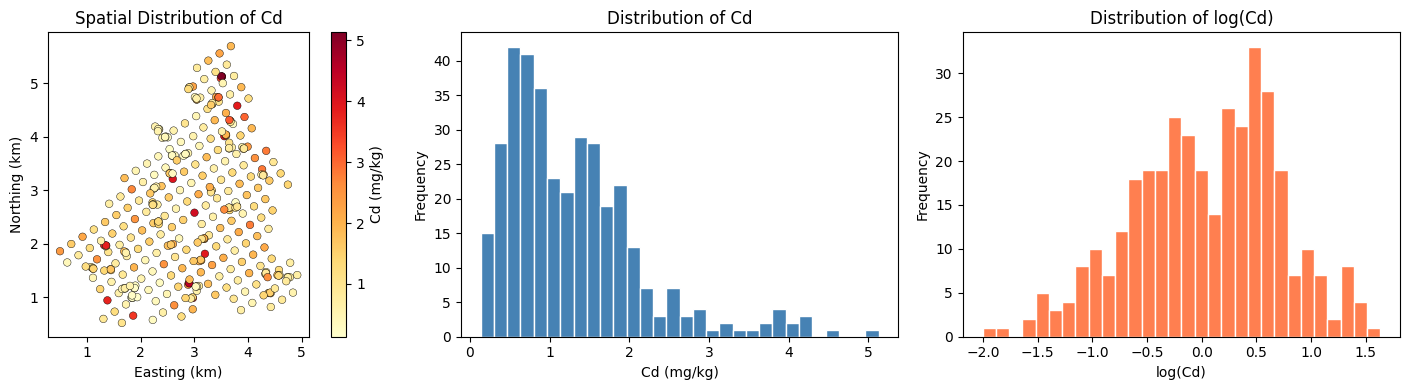


log(Cd) skewness: -0.248  (|skew| < 1 is preferable for variogram modeling)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Spatial scatter
sc = axes[0].scatter(df[x_col], df[y_col], c=z, cmap="YlOrRd", s=30, edgecolors="k", linewidths=0.3)
plt.colorbar(sc, ax=axes[0], label=f"{target} (mg/kg)")
axes[0].set_title(f"Spatial Distribution of {target}")
axes[0].set_xlabel("Easting (km)"); axes[0].set_ylabel("Northing (km)")
axes[0].set_aspect("equal")

# Histogram
axes[1].hist(z, bins=30, color="steelblue", edgecolor="white")
axes[1].set_title(f"Distribution of {target}")
axes[1].set_xlabel(f"{target} (mg/kg)"); axes[1].set_ylabel("Frequency")

# Log-transformed histogram
log_z = np.log(z + 1e-6)
axes[2].hist(log_z, bins=30, color="coral", edgecolor="white")
axes[2].set_title(f"Distribution of log({target})")
axes[2].set_xlabel(f"log({target})"); axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"\nlog({target}) skewness: {skew(log_z):.3f}  (|skew| < 1 is preferable for variogram modeling)")

# Use log-transformed values for variogram modeling (reduces skew)
z_model = log_z
print("Using log-transformed Cd for variogram modeling.")

In [6]:
# Use log-transformed values for variogram modeling (reduces skew effect)
z_model = log_z
print("Using log-transformed Cd for variogram modeling.")

Using log-transformed Cd for variogram modeling.


***
## 6. CPU vs GPU Timing

Section 4.1 showed how to *select* a backend. Here we measure how long `Variogram.fit()` takes on **CPU** (`use_gpu=False`, NumPy/SciPy) versus **GPU** (`use_gpu=True`, CuPy) - first on the Jura samples ($n = 359$), then on prefixes of the Great Plains soil-organic-carbon survey (`data/gp_data_5000.csv`, $n$ up to 5{,}000).

The empirical (experimental) variogram is the GPU-accelerated step: it builds an $n \times n$ pairwise-distance matrix. Theoretical-model fitting (nugget / sill / range) always runs on the CPU and is cheap once the lag cloud is in hand.

Two practical notes:

- **Small $n$** (a few hundred points, like Jura) often shows little GPU gain: host→device copies and kernel-launch overhead dominate.
- **Larger $n$** is where the GPU pays off, because pairwise distances scale as $O(n^2)$.

Each timing is the **median** of three `Variogram.fit()` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped and only CPU times are reported.


GPU usable : True
Repeats    : 3  (median wall time of Variogram.fit())
GP SOC     : 5000 samples from data/gp_data_5000.csv

  dataset    n  CPU (ms)  GPU (ms) speedup  match
Jura (Cd)  359      11.4      11.8   0.97×   True
 GP (SOC)  500      14.6      10.2   1.43×   True
 GP (SOC) 1000      63.7      14.7   4.32×   True
 GP (SOC) 2000     305.7      28.7  10.67×   True
 GP (SOC) 4000    1321.1      88.6  14.91×   True
 GP (SOC) 5000    2028.5     136.0  14.92×   True


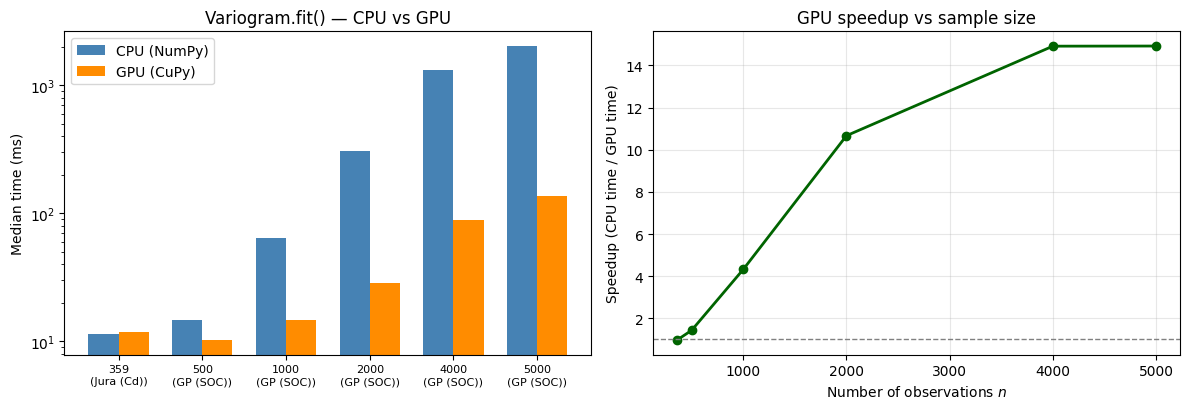

In [6]:
import time

N_LAGS = 15
N_REPEATS = 3

df_gp = pd.read_csv("../data/gp_data_5000.csv")
gp_coords = df_gp[["x", "y"]].to_numpy(dtype=float)
gp_vals = df_gp["SOC"].to_numpy(dtype=float)
SIZES = [len(coords), 500, 1000, 2000, 4000, len(gp_coords)]


def _time_variogram(xy, values, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of Variogram.fit() over *repeats* runs."""
    if warmup:
        k = min(80, len(xy))
        Variogram(xy[:k], values[:k], model="spherical",
                  n_lags=10, use_gpu=use_gpu).fit()
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        last = Variogram(xy, values, model="spherical",
                         n_lags=N_LAGS, use_gpu=use_gpu).fit()
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of Variogram.fit())")
print(f"GP SOC     : {len(gp_vals)} samples from data/gp_data_5000.csv")
print()

rows = []

for n in SIZES:
    if n == len(coords):
        xy, vals, label = coords, z_model, "Jura (Cd)"
    else:
        xy, vals = gp_coords[:n], gp_vals[:n]
        label = "GP (SOC)"

    cpu_t, v_cpu = _time_variogram(xy, vals, use_gpu=False)
    row = {
        "n": n, "dataset": label,
        "CPU (s)": cpu_t, "GPU (s)": np.nan,
        "speedup": np.nan, "match": "—",
    }

    if USE_GPU:
        gpu_t, v_gpu = _time_variogram(xy, vals, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        row["match"] = bool(np.allclose(
            v_cpu.experimental, v_gpu.experimental, rtol=1e-5, equal_nan=True
        ))
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [f"{int(n)}\n({lab})" for n, lab in zip(n_vals, df_bench["dataset"])],
    fontsize=8,
)
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("Variogram.fit() — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Number of observations $n$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs sample size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


The experimental clouds from the two backends should **match** (`match = True`). On this workstation the Jura sample ($n = 359$) is too small for a meaningful GPU win; on the Great Plains SOC prefixes the $O(n^2)$ pairwise distances dominate by $n = 2{,}000$–$5{,}000$ and the GPU is several times faster. Use `use_gpu=USE_GPU` (as the rest of this notebook does) so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 7. Empirical Variogram - Robust Estimators

The **empirical (experimental) variogram** is computed from data before fitting any theoretical model.
PyGStat provides three estimators:

| Estimator           | Formula                                                                                                         | Sensitivity to outliers   |
|---------------------|---------------------------------------------------------------------------------------------------------------|--------------------------|
| **Matheron**        | $\hat{\gamma}(h) = \frac{1}{2N(h)}\sum_{i=1}^{N(h)}[Z(x_i)-Z(x_i+h)]^2$                                       | High (classical)         |
| **Cressie–Hawkins** | $\hat{\gamma}(h) = \frac{1}{2} \frac{\left(\frac{1}{N} \sum \sqrt{\left| \Delta Z \right|} \right)^4}{0.457 + 0.494/N}$ | Moderate                 |
| **Dowd**            | $\hat{\gamma}(h) = \frac{1}{2} \cdot 2.198 \cdot \text{median}(\Delta Z^2)$                                   | Low (most robust)        |

### 7.1 Matheron Estimator

Empirical variogram backend: GPU (CuPy)
Nugget: 0.2474  Sill: 0.2304  Range: 1.2611 km


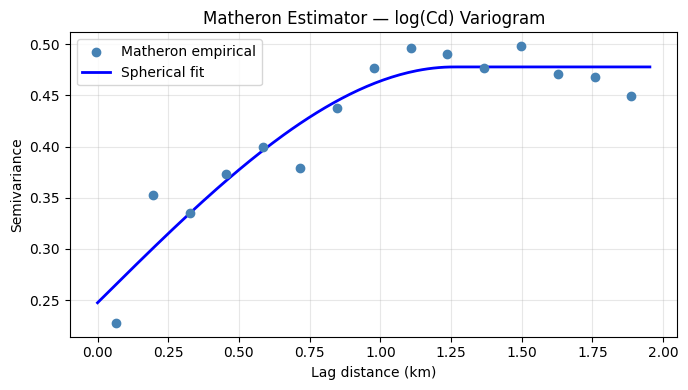

In [7]:
# z_model is log(Cd), set in §5. Rebuild it if that cell was skipped.
if "z_model" not in globals():
    z_model = np.log(z + 1e-6)

v_matheron = Variogram(
    coords=coords,
    values=z_model,
    model="spherical",
    estimator="matheron",
    n_lags=15,
    use_gpu=USE_GPU,
)
v_matheron.fit()
print(f"Empirical variogram backend: {'GPU (CuPy)' if v_matheron.use_gpu else 'CPU (NumPy)'}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(v_matheron.lags, v_matheron.experimental, color="steelblue", zorder=5, label="Matheron empirical")
h_fine = np.linspace(0, v_matheron.maxlag, 200)
ax.plot(h_fine, v_matheron(h_fine), "b-", lw=2, label="Spherical fit")
ax.set_xlabel("Lag distance (km)"); ax.set_ylabel("Semivariance")
ax.set_title("Matheron Estimator — log(Cd) Variogram")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

p = v_matheron.fitted_params
print(f"Nugget: {p[0]:.4f}  Sill: {p[1]:.4f}  Range: {p[2]:.4f} km")


### 7.2 Cressie–Hawkins Estimator

The **Cressie–Hawkins estimator** is a robust alternative to the classical Matheron estimator for computing empirical variograms. It is less sensitive to outliers because it uses a formula based on the fourth power of the average square root of absolute pairwise differences:

$$
\hat{\gamma}(h) = \frac{1}{2} \frac{\left(\frac{1}{N} \sum \sqrt{|\Delta Z|} \right)^4}{0.457 + 0.494/N}
$$

Here, $\Delta Z = Z(x_i) - Z(x_i + h)$ represents the difference in measured values at points separated by lag $h$, and $N$ is the number of pairs for that lag. This estimator provides more robust estimates of spatial variability in the presence of skewed data or outliers often encountered in geoscientific datasets.

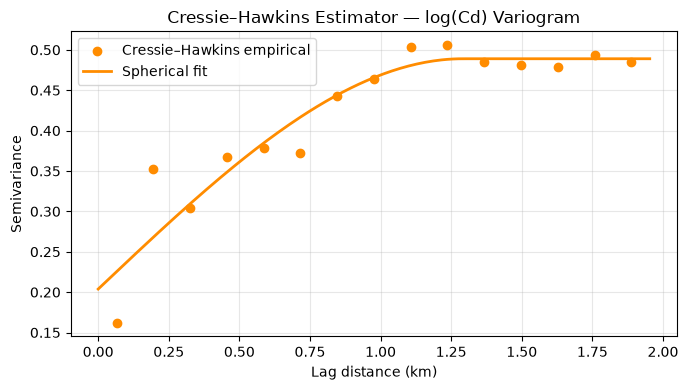

Nugget: 0.2038  Sill: 0.2852  Range: 1.2912 km


In [7]:
v_cressie = Variogram(
    coords=coords,
    values=z_model,
    model="spherical",
    estimator="cressie",
    n_lags=15,
    use_gpu=USE_GPU,
)
v_cressie.fit()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(v_cressie.lags, v_cressie.experimental, color="darkorange", zorder=5, label="Cressie–Hawkins empirical")
ax.plot(h_fine, v_cressie(h_fine), color="darkorange", lw=2, label="Spherical fit")
ax.set_xlabel("Lag distance (km)"); ax.set_ylabel("Semivariance")
ax.set_title("Cressie–Hawkins Estimator — log(Cd) Variogram")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

p = v_cressie.fitted_params
print(f"Nugget: {p[0]:.4f}  Sill: {p[1]:.4f}  Range: {p[2]:.4f} km")


### 7.3 Dowd Estimator

The **Dowd estimator** is another robust method for calculating empirical variograms, particularly designed to reduce the influence of outliers and non-Gaussian data often encountered in environmental and geoscientific datasets. Unlike the classical Matheron estimator, the Dowd estimator leverages the median of pairwise differences, making it more resistant to anomalies.

The Dowd estimator for the semivariance at lag $h$ can be expressed as:

$$
\hat{\gamma}_{\text{Dowd}}(h) = \frac{1}{2} \text{median} \big( |\Delta Z| \big),
$$

where $\Delta Z = Z(x_i) - Z(x_i+h)$ represents all pairwise differences of sample values separated by lag $h$. By using the median rather than the mean or squared differences, the Dowd estimator limits the impact of extreme values and provides a more robust assessment of spatial continuity in the presence of outliers.

This estimator is beneficial when working with datasets where normality cannot be assumed or when the data distribution is skewed or heavy-tailed.

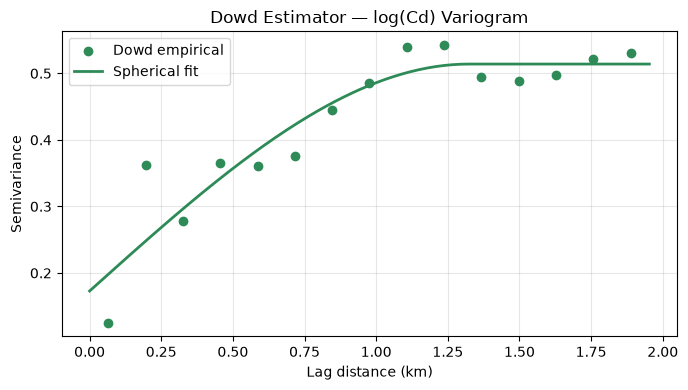

Nugget: 0.1729  Sill: 0.3410  Range: 1.3232 km


In [8]:
v_dowd = Variogram(
    coords=coords,
    values=z_model,
    model="spherical",
    estimator="dowd",
    n_lags=15,
    use_gpu=USE_GPU,
)
v_dowd.fit()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(v_dowd.lags, v_dowd.experimental, color="seagreen", zorder=5, label="Dowd empirical")
ax.plot(h_fine, v_dowd(h_fine), color="seagreen", lw=2, label="Spherical fit")
ax.set_xlabel("Lag distance (km)"); ax.set_ylabel("Semivariance")
ax.set_title("Dowd Estimator — log(Cd) Variogram")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

p = v_dowd.fitted_params
print(f"Nugget: {p[0]:.4f}  Sill: {p[1]:.4f}  Range: {p[2]:.4f} km")


### 7.4 Estimator Comparison

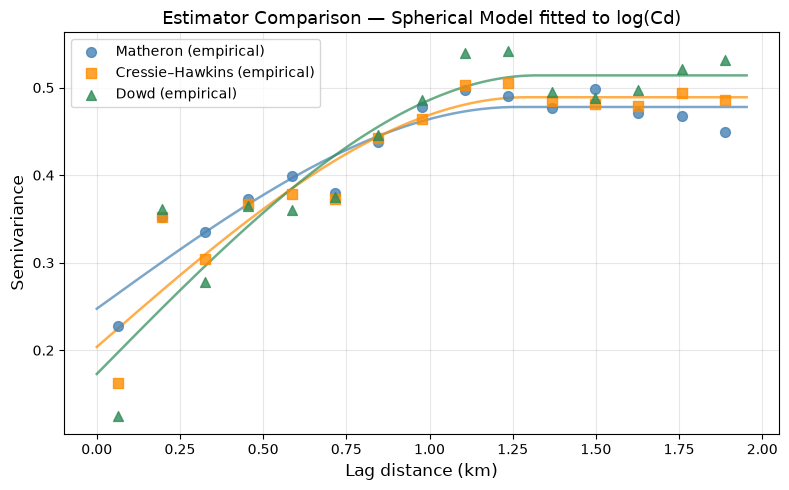

,Nugget,Sill,Range (km)
Estimator,,,
Matheron,0.2474,0.2304,1.2611
Cressie–Hawkins,0.2038,0.2852,1.2912
Dowd,0.1729,0.3410,1.3232


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

estimator_results = {
    "Matheron": (v_matheron, "steelblue", "o"),
    "Cressie–Hawkins": (v_cressie, "darkorange", "s"),
    "Dowd": (v_dowd, "seagreen", "^"),
}

for name, (v, color, marker) in estimator_results.items():
    ax.scatter(v.lags, v.experimental, color=color, marker=marker, s=50,
               label=f"{name} (empirical)", zorder=5, alpha=0.8)
    ax.plot(h_fine, v(h_fine), color=color, lw=1.8, alpha=0.7)

ax.set_xlabel("Lag distance (km)", fontsize=12)
ax.set_ylabel("Semivariance", fontsize=12)
ax.set_title("Estimator Comparison — Spherical Model fitted to log(Cd)", fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Summary table
rows = []
for name, (v, _, _) in estimator_results.items():
    p = v.fitted_params
    rows.append({"Estimator": name, "Nugget": round(p[0], 4),
                 "Sill": round(p[1], 4), "Range (km)": round(p[2], 4)})
pd.DataFrame(rows).set_index("Estimator")

***
## 8. Isotropic Variogram Modeling

We now fit all six theoretical models to the experimental variogram computed with the **Matheron** estimator.

### 8.1 Spherical Model

The spherical model is the most widely used in environmental and earth sciences. It has a **finite range** and shows **linear behavior near the origin**.

$$\gamma(h) = C_0 + C \left[\frac{3h}{2a} - \frac{h^3}{2a^3}\right] \quad h \le a; \quad C_0 + C \quad h > a$$

In [10]:
v_sph = Variogram(coords=coords, values=z_model, model="spherical",
                  estimator="matheron", n_lags=15, use_gpu=USE_GPU)
v_sph.fit()
p = v_sph.fitted_params
print(f"Spherical  →  Nugget={p[0]:.4f}  Sill={p[1]:.4f}  Range={p[2]:.4f} km")


Spherical  →  Nugget=0.2474  Sill=0.2304  Range=1.2611 km


### 8.2 Exponential Model

The exponential model has an **infinite theoretical range** but a practical range of $\approx 3a$. It is appropriate for phenomena with abrupt transitions.

$$\gamma(h) = C_0 + C\left[1 - e^{-h/a}\right]$$

In [11]:
v_exp = Variogram(coords=coords, values=z_model, model="exponential",
                  estimator="matheron", n_lags=15, use_gpu=USE_GPU)
v_exp.fit()
p = v_exp.fitted_params
print(f"Exponential →  Nugget={p[0]:.4f}  Sill={p[1]:.4f}  Range={p[2]:.4f} km  (practical range ≈ {3*p[2]:.4f})")


Exponential →  Nugget=0.2096  Sill=0.2779  Range=0.4678 km  (practical range ≈ 1.4035)


### 8.3 Gaussian Model

The Gaussian model produces very **smooth** spatial fields with a **parabolic behavior near the origin**. Use with caution — it can produce numerical instability in kriging systems.

$$\gamma(h) = C_0 + C\left[1 - e^{-(h/a)^2}\right]$$

In [12]:
v_gau = Variogram(coords=coords, values=z_model, model="gaussian",
                  estimator="matheron", n_lags=15, use_gpu=USE_GPU)
v_gau.fit()
p = v_gau.fitted_params
print(f"Gaussian   →  Nugget={p[0]:.4f}  Sill={p[1]:.4f}  Range={p[2]:.4f} km")


Gaussian   →  Nugget=0.2791  Sill=0.1994  Range=0.6222 km


### 8.4 Matérn Model

The **Matérn** class is a flexible family parameterized by smoothness $\nu$. Special cases include the exponential ($\nu=0.5$) and, in the limit, the Gaussian. It is the most principled choice when the smoothness of the underlying process is uncertain.

$$\gamma(h) = C_0 + C\left[1 - \frac{2^{1-\nu}}{\Gamma(\nu)}\left(\frac{\sqrt{2\nu}h}{a}\right)^\nu K_\nu\left(\frac{\sqrt{2\nu}h}{a}\right)\right]$$

GPU note: Matérn always *evaluates* on CPU (SciPy's modified Bessel $K_\nu$ has no CuPy equivalent), transferring a GPU array over and back transparently. The empirical cloud is still GPU-accelerated when `use_gpu=True`.


In [13]:
v_mat = Variogram(coords=coords, values=z_model, model="matern",
                  estimator="matheron", n_lags=15, use_gpu=USE_GPU)
v_mat.fit()
p = v_mat.fitted_params
print(f"Matérn     →  Nugget={p[0]:.4f}  Sill={p[1]:.4f}  Range={p[2]:.4f} km  ν={p[3]:.4f}")


Matérn     →  Nugget=0.1576  Sill=0.3345  Range=0.6146 km  ν=0.3000


### 8.5 Stable Model

The **stable** model generalizes the exponential and Gaussian through the power parameter $\alpha \in (0,2]$:
- $\alpha=1$: exponential
- $\alpha=2$: Gaussian

$$\gamma(h) = C_0 + C\left[1 - e^{-(h/a)^\alpha}\right]$$

In [14]:
v_sta = Variogram(coords=coords, values=z_model, model="stable",
                  estimator="matheron", n_lags=15, use_gpu=USE_GPU)
v_sta.fit()
p = v_sta.fitted_params
print(f"Stable     →  Nugget={p[0]:.4f}  Sill={p[1]:.4f}  Range={p[2]:.4f} km  α={p[3]:.4f}")


Stable     →  Nugget=0.2083  Sill=0.2795  Range=0.4659 km  α=0.9910


### 8.6 Cubic Model

The **cubic** model has a compact support (finite range) and is twice-differentiable at the origin, making it appropriate for very smooth phenomena.

$$\gamma(h) = C_0 + C\left[7\left(\frac{h}{a}\right)^2 - \frac{35}{4}\left(\frac{h}{a}\right)^3 + \frac{7}{2}\left(\frac{h}{a}\right)^5 - \frac{3}{4}\left(\frac{h}{a}\right)^7\right] \quad h \le a$$

In [15]:
v_cub = Variogram(coords=coords, values=z_model, model="cubic",
                  estimator="matheron", n_lags=15, use_gpu=USE_GPU)
v_cub.fit()
p = v_cub.fitted_params
print(f"Cubic      →  Nugget={p[0]:.4f}  Sill={p[1]:.4f}  Range={p[2]:.4f} km")


Cubic      →  Nugget=0.2788  Sill=0.1990  Range=1.4993 km


### 8.7 All Models Compared

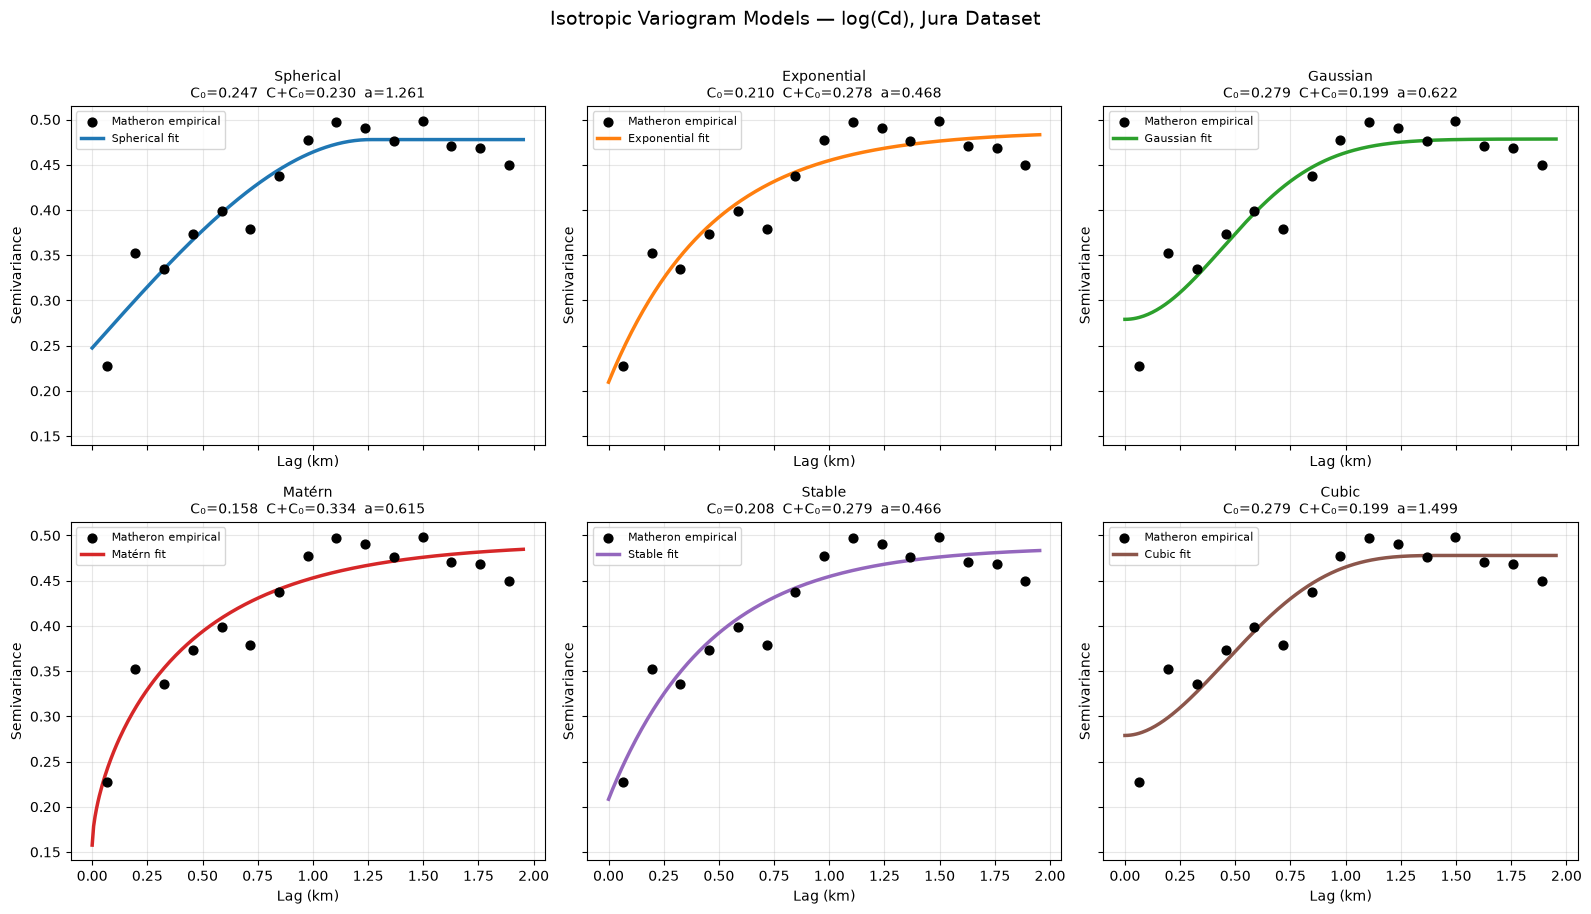

In [16]:
models_dict = {
    "Spherical":    (v_sph,  "#1f77b4"),
    "Exponential":  (v_exp,  "#ff7f0e"),
    "Gaussian":     (v_gau,  "#2ca02c"),
    "Matérn":       (v_mat,  "#d62728"),
    "Stable":       (v_sta,  "#9467bd"),
    "Cubic":        (v_cub,  "#8c564b"),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.ravel()

# Empirical points from Matheron
emp_lags = v_matheron.lags
emp_vals = v_matheron.experimental
h_fine = np.linspace(0, v_matheron.maxlag, 300)

for ax, (name, (v, color)) in zip(axes, models_dict.items()):
    ax.scatter(emp_lags, emp_vals, color="black", s=40, zorder=5, label="Matheron empirical")
    fitted_curve = v(h_fine)
    ax.plot(h_fine, fitted_curve, color=color, lw=2.5, label=f"{name} fit")
    p = v.fitted_params
    info = f"C₀={p[0]:.3f}  C+C₀={p[1]:.3f}  a={p[2]:.3f}"
    ax.set_title(f"{name}\n{info}", fontsize=10)
    ax.set_xlabel("Lag (km)"); ax.set_ylabel("Semivariance")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Isotropic Variogram Models — log(Cd), Jura Dataset", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

***
## 9. Anisotropic Variogram Modeling

Many geological phenomena exhibit **geometric anisotropy**: spatial continuity is stronger along one direction (e.g., along a river valley, a sedimentary layer, or a mineralized vein). To detect this, we examine **directional variograms** and then fit an anisotropic model.

PyGStat's `Variogram` accepts an `anisotropy` dict with keys:
- `angle`: rotation angle in degrees (0° = East, increases counter-clockwise)
- `ratio`: range ratio = major range / minor range (≥ 1)

The anisotropy transformation rotates and rescales coordinates before computing the isotropic variogram.

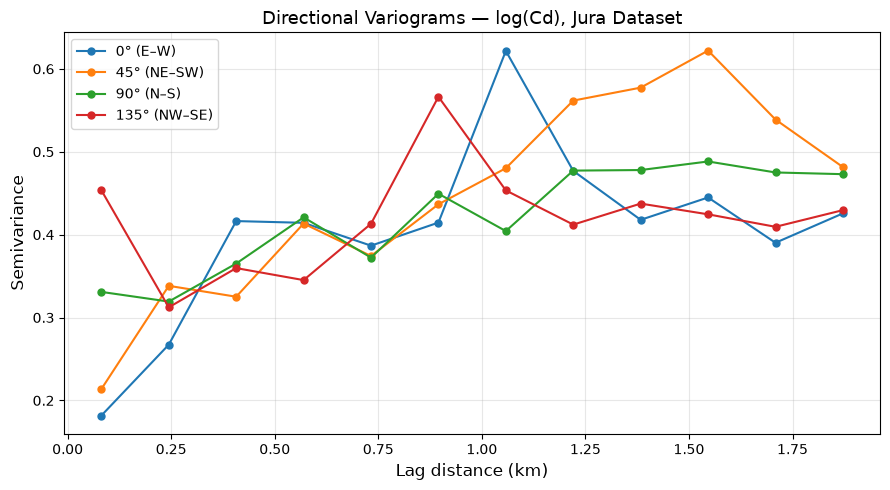

Inspect the plot: directions with lower semivariance at large lags indicate stronger continuity.


In [17]:
# ── Compute directional variograms manually to detect anisotropy ──────────────
from scipy.spatial.distance import pdist, squareform

def directional_variogram(coords, values, angle_deg, tol_deg=22.5, n_lags=12, maxlag=None):
    """Compute a directional empirical variogram."""
    angle_rad = np.deg2rad(angle_deg)
    tol_rad   = np.deg2rad(tol_deg)

    dx = coords[:, 0][:, None] - coords[:, 0][None, :]
    dy = coords[:, 1][:, None] - coords[:, 1][None, :]
    dists = np.sqrt(dx**2 + dy**2)
    bearings = np.arctan2(dy, dx)

    # Fold so that opposing directions are equivalent
    diff_angle = np.abs((bearings - angle_rad + np.pi) % (2 * np.pi) - np.pi)
    diff_angle = np.minimum(diff_angle, np.pi - diff_angle)
    in_direction = diff_angle <= tol_rad

    if maxlag is None:
        maxlag = np.percentile(dists[dists > 0], 50)

    bins = np.linspace(0, maxlag, n_lags + 1)
    centers = (bins[:-1] + bins[1:]) / 2
    gamma = []
    val_diff = values[:, None] - values[None, :]

    for i in range(n_lags):
        mask = in_direction & (dists > bins[i]) & (dists <= bins[i+1])
        if mask.sum() > 0:
            gamma.append(0.5 * np.mean(val_diff[mask]**2))
        else:
            gamma.append(np.nan)
    return centers, np.array(gamma)


angles = [0, 45, 90, 135]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
labels = ["0° (E–W)", "45° (NE–SW)", "90° (N–S)", "135° (NW–SE)"]

fig, ax = plt.subplots(figsize=(9, 5))
for ang, col, lab in zip(angles, colors, labels):
    lags_d, gamma_d = directional_variogram(coords, z_model, angle_deg=ang, n_lags=12)
    ax.plot(lags_d, gamma_d, "o-", color=col, lw=1.5, markersize=5, label=lab)

ax.set_xlabel("Lag distance (km)", fontsize=12)
ax.set_ylabel("Semivariance", fontsize=12)
ax.set_title("Directional Variograms — log(Cd), Jura Dataset", fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Inspect the plot: directions with lower semivariance at large lags indicate stronger continuity.")

Anisotropic Spherical (angle=45°, ratio=2):
  Nugget=0.2455  Sill=0.2442  Range (major)=1.6664 km
  Minor range ≈ 0.8332 km


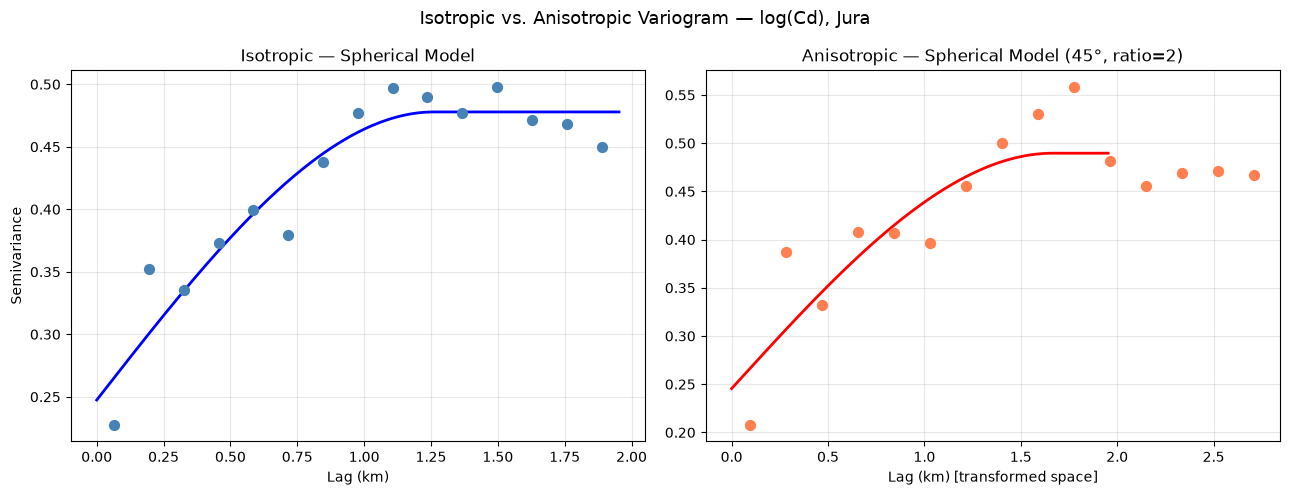

In [18]:
# ── Fit anisotropic variogram model ──────────────────────────────────────────
# Suppose the major direction of continuity is 45° (NE–SW) with ratio 2:1
# Adjust these based on what you observe in the directional variogram above.

v_aniso = Variogram(
    coords=coords,
    values=z_model,
    model="spherical",
    estimator="matheron",
    n_lags=15,
    anisotropy={"angle": 45.0, "ratio": 2.0},
    use_gpu=USE_GPU,
)
v_aniso.fit()
p = v_aniso.fitted_params
print(f"Anisotropic Spherical (angle=45°, ratio=2):")
print(f"  Nugget={p[0]:.4f}  Sill={p[1]:.4f}  Range (major)={p[2]:.4f} km")
print(f"  Minor range ≈ {p[2]/2:.4f} km")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Isotropic
axes[0].scatter(v_sph.lags, v_sph.experimental, color="steelblue", s=50, zorder=5)
axes[0].plot(h_fine, v_sph(h_fine), "b-", lw=2)
axes[0].set_title("Isotropic — Spherical Model")
axes[0].set_xlabel("Lag (km)"); axes[0].set_ylabel("Semivariance")
axes[0].grid(alpha=0.3)

# Anisotropic (in transformed space)
axes[1].scatter(v_aniso.lags, v_aniso.experimental, color="coral", s=50, zorder=5)
axes[1].plot(h_fine, v_aniso(h_fine), "r-", lw=2)
axes[1].set_title("Anisotropic — Spherical Model (45°, ratio=2)")
axes[1].set_xlabel("Lag (km) [transformed space]")
axes[1].grid(alpha=0.3)

plt.suptitle("Isotropic vs. Anisotropic Variogram — log(Cd), Jura", fontsize=13)
plt.tight_layout(); plt.show()


#### Anisotropy Grid Search

To systematically find the best anisotropy parameters, we can perform a grid search over candidate angles and ratios and choose the combination that minimises the residual sum of squares.

Best anisotropy → angle=165°  ratio=2.5  RSS=0.002403


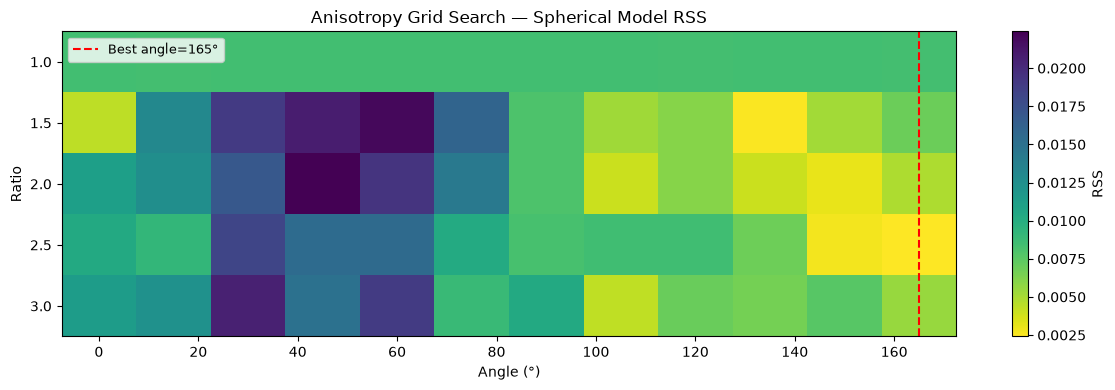

In [19]:
def compute_rss(v):
    """Residual sum of squares between empirical and fitted variogram."""
    obs = v.experimental
    mask = ~np.isnan(obs)
    pred = v(v.lags)
    return float(np.sum((pred[mask] - obs[mask]) ** 2))

candidate_angles = np.arange(0, 180, 15)          # 0, 15, ..., 165
candidate_ratios = [1.0, 1.5, 2.0, 2.5, 3.0]     # ratio ≥ 1

best_rss = np.inf
best_angle, best_ratio = None, None
results_grid = []

for ang in candidate_angles:
    for ratio in candidate_ratios:
        try:
            v_tmp = Variogram(
                coords=coords, values=z_model,
                model="spherical", estimator="matheron",
                n_lags=15,
                anisotropy={"angle": float(ang), "ratio": float(ratio)},
                use_gpu=USE_GPU,
            )
            v_tmp.fit()
            rss = compute_rss(v_tmp)
            results_grid.append({"angle": ang, "ratio": ratio, "RSS": rss})
            if rss < best_rss:
                best_rss = rss
                best_angle, best_ratio = ang, ratio
        except Exception:
            continue

print(f"Best anisotropy → angle={best_angle}°  ratio={best_ratio}  RSS={best_rss:.6f}")

# Heatmap of RSS over angle × ratio
df_grid = pd.DataFrame(results_grid).pivot(index="ratio", columns="angle", values="RSS")

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(df_grid.values, aspect="auto", cmap="viridis_r",
               extent=[candidate_angles.min()-7.5, candidate_angles.max()+7.5,
                       candidate_ratios[-1]+0.25, candidate_ratios[0]-0.25])
plt.colorbar(im, ax=ax, label="RSS")
ax.set_xlabel("Angle (°)"); ax.set_ylabel("Ratio")
ax.set_title("Anisotropy Grid Search — Spherical Model RSS")
ax.axvline(best_angle, color="red", lw=1.5, ls="--", label=f"Best angle={best_angle}°")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


***
## 10. Best-Fitting Model Selection

We evaluate all six theoretical models against the Matheron experimental variogram using:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RSS** | $\sum_k[\hat{\gamma}(h_k) - \gamma(h_k;\hat{\theta})]^2$ | Absolute goodness-of-fit; lower is better |
| **RMSE** | $\sqrt{\text{RSS}/K}$ | Root mean squared error; interpretable in variogram units |
| **R²** | $1 - \text{RSS}/\text{TSS}$ | Proportion of variance explained; higher is better |
| **AIC** | $K \ln(\text{RSS}/K) + 2p$ | Penalizes model complexity ($p$ = number of parameters) |
| **BIC** | $K \ln(\text{RSS}/K) + p\ln(K)$ | Stronger penalty for complex models |

In [20]:
def model_metrics(v, n_params):
    """Compute RSS, RMSE, R², AIC, BIC for a fitted Variogram object."""
    obs  = v.experimental
    mask = ~np.isnan(obs)
    obs_valid = obs[mask]
    pred = v(v.lags)[mask]
    K    = mask.sum()

    rss  = float(np.sum((pred - obs_valid) ** 2))
    rmse = float(np.sqrt(rss / K))
    tss  = float(np.sum((obs_valid - obs_valid.mean()) ** 2))
    r2   = 1.0 - rss / tss if tss > 0 else np.nan

    if rss > 0 and K > 0:
        aic = K * np.log(rss / K) + 2 * n_params
        bic = K * np.log(rss / K) + n_params * np.log(K)
    else:
        aic = bic = -np.inf

    return {"RSS": round(rss, 6), "RMSE": round(rmse, 6),
            "R²": round(r2, 4), "AIC": round(aic, 4), "BIC": round(bic, 4)}


# Number of free parameters per model
n_params_map = {
    "Spherical":   3,   # nugget, sill, range
    "Exponential": 3,
    "Gaussian":    3,
    "Matérn":      4,   # + nu
    "Stable":      4,   # + alpha
    "Cubic":       3,
}

all_models = {
    "Spherical":   v_sph,
    "Exponential": v_exp,
    "Gaussian":    v_gau,
    "Matérn":      v_mat,
    "Stable":      v_sta,
    "Cubic":       v_cub,
}

records = []
for name, v in all_models.items():
    m = model_metrics(v, n_params_map[name])
    p = v.fitted_params
    row = {"Model": name, "Nugget": round(p[0], 4),
           "Sill": round(p[1], 4), "Range (km)": round(p[2], 4)}
    if len(p) > 3:
        row["Extra param"] = round(p[3], 4)
    else:
        row["Extra param"] = "—"
    row.update(m)
    records.append(row)

df_metrics = pd.DataFrame(records).set_index("Model")
df_metrics = df_metrics.sort_values("AIC")

# Highlight best model
best_model_name = df_metrics.index[0]
print(f"\n{'='*60}")
print(f"  BEST FITTING MODEL: {best_model_name}")
print(f"{'='*60}\n")

df_metrics.style.background_gradient(subset=["AIC", "BIC", "RSS"], cmap="RdYlGn_r") \
               .background_gradient(subset=["R²"], cmap="RdYlGn")


  BEST FITTING MODEL: Spherical



,Nugget,Sill,Range (km),Extra param,RSS,RMSE,R²,AIC,BIC
Model,,,,,,,,,
Spherical,0.247400,0.230400,1.261100,—,0.008427,0.023702,0.897800,-106.266300,-104.142200
Exponential,0.209600,0.277900,0.467800,—,0.009500,0.025167,0.884800,-104.467200,-102.343000
Cubic,0.278800,0.199000,1.499300,—,0.010417,0.026352,0.873600,-103.085900,-100.961800
Matérn,0.157600,0.334500,0.614600,0.300000,0.009407,0.025043,0.885900,-102.615000,-99.782800
Stable,0.208300,0.279500,0.465900,0.991000,0.009500,0.025166,0.884800,-102.467400,-99.635200
Gaussian,0.279100,0.199400,0.622200,—,0.010913,0.026972,0.867600,-102.388400,-100.264200


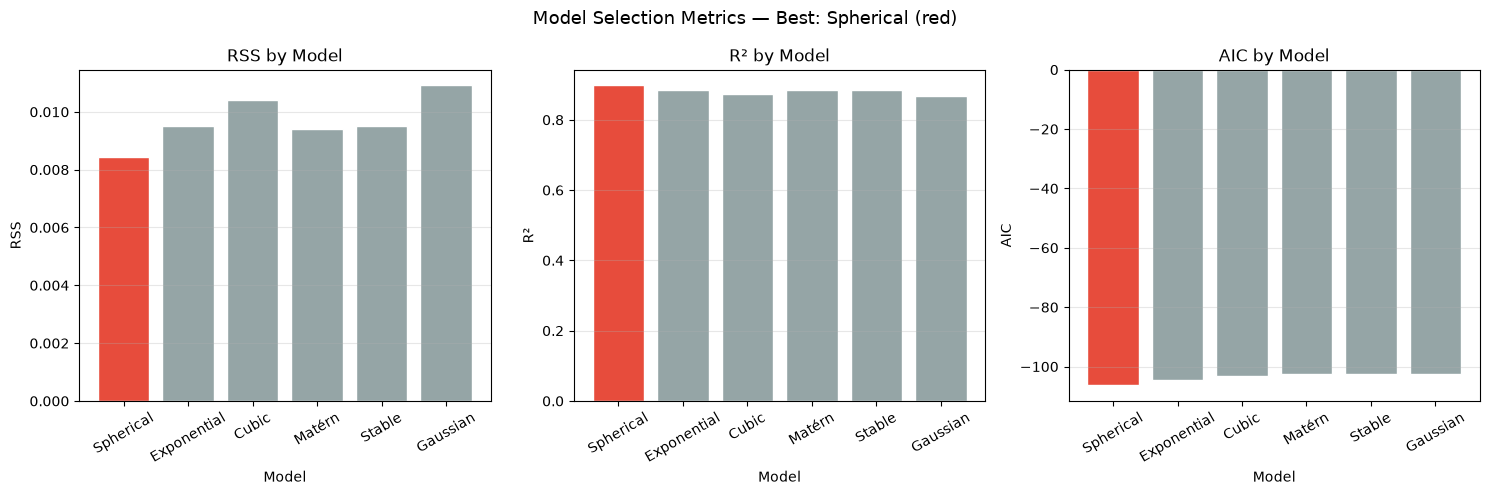

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ["RSS", "R²", "AIC"]
colors_bar = ["#e74c3c" if name == best_model_name else "#95a5a6" for name in df_metrics.index]

for ax, metric in zip(axes, metrics_to_plot):
    vals = df_metrics[metric]
    bars = ax.bar(df_metrics.index, vals, color=colors_bar, edgecolor="white")
    ax.set_title(f"{metric} by Model", fontsize=12)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Model Selection Metrics — Best: {best_model_name} (red)", fontsize=13)
plt.tight_layout(); plt.show()

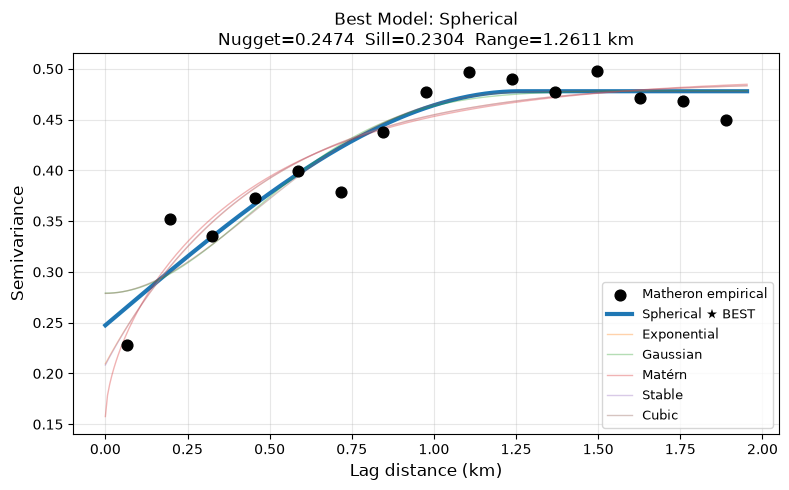


Fitted parameters of the best model:
  Nugget (C₀)         : 0.247444
  Sill (C₀+C)         : 0.230427
  Range (a)           : 1.261063


In [22]:
# ── Final best model plot ─────────────────────────────────────────────────────
v_best = all_models[best_model_name]
p_best = v_best.fitted_params

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(v_matheron.lags, v_matheron.experimental,
           color="black", s=60, zorder=6, label="Matheron empirical")

# Plot all models lightly
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
for (name, v), col in zip(all_models.items(), palette):
    lw = 3.0 if name == best_model_name else 1.0
    alpha = 1.0 if name == best_model_name else 0.35
    ax.plot(h_fine, v(h_fine), color=col, lw=lw, alpha=alpha,
            label=name + (" ★ BEST" if name == best_model_name else ""))

title = (f"Best Model: {best_model_name}\n"
         f"Nugget={p_best[0]:.4f}  Sill={p_best[1]:.4f}  Range={p_best[2]:.4f} km")
ax.set_title(title, fontsize=12)
ax.set_xlabel("Lag distance (km)", fontsize=12)
ax.set_ylabel("Semivariance", fontsize=12)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nFitted parameters of the best model:")
param_names = ["Nugget (C₀)", "Sill (C₀+C)", "Range (a)"]
if len(p_best) > 3:
    extra = "ν" if best_model_name == "Matérn" else "α"
    param_names.append(extra)
for pname, pval in zip(param_names, p_best):
    print(f"  {pname:20s}: {pval:.6f}")

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# STANDALONE SCRIPT — Best-Fitting Variogram Model Selector
# Copy this cell to a .py file for production use.
# ══════════════════════════════════════════════════════════════════════════════

def find_best_variogram(
    coords,
    values,
    estimator="matheron",
    n_lags=15,
    criterion="AIC",
    verbose=True,
    use_gpu=USE_GPU,
):
    """
    Fit all standard variogram models and return the best one.

    Parameters
    ----------
    coords     : array-like, shape (n, 2)   — spatial coordinates
    values     : array-like, shape (n,)     — observed values
    estimator  : str — 'matheron', 'cressie', or 'dowd'
    n_lags     : int — number of lag classes
    criterion  : str — 'AIC', 'BIC', 'RSS', or 'R²'
    verbose    : bool — print ranking table
    use_gpu    : bool or 'auto' — empirical variogram backend (see §4.1)

    Returns
    -------
    best_name  : str              — name of the winning model
    best_v     : Variogram        — fitted Variogram object
    df_results : pd.DataFrame     — full ranking table
    """
    models = ["spherical", "exponential", "gaussian", "matern", "stable", "cubic"]
    n_params = {"spherical": 3, "exponential": 3, "gaussian": 3,
                "matern": 4, "stable": 4, "cubic": 3}

    fitted = {}
    records = []

    for model_name in models:
        try:
            v = Variogram(
                coords=np.asarray(coords, dtype=float),
                values=np.asarray(values, dtype=float),
                model=model_name,
                estimator=estimator,
                n_lags=n_lags,
                use_gpu=use_gpu,
            )
            v.fit()

            obs  = v.experimental
            mask = ~np.isnan(obs)
            obs_v = obs[mask]
            pred  = v(v.lags)[mask]
            K = mask.sum()
            p = n_params[model_name]

            rss  = float(np.sum((pred - obs_v) ** 2))
            rmse = float(np.sqrt(rss / K)) if K > 0 else np.nan
            tss  = float(np.sum((obs_v - obs_v.mean()) ** 2))
            r2   = 1.0 - rss / tss if tss > 0 else np.nan
            aic  = K * np.log(rss / K) + 2 * p if rss > 0 else -np.inf
            bic  = K * np.log(rss / K) + p * np.log(K) if rss > 0 else -np.inf

            fitted[model_name] = v
            records.append({
                "Model": model_name.capitalize(),
                "Nugget": round(v.fitted_params[0], 5),
                "Sill":   round(v.fitted_params[1], 5),
                "Range":  round(v.fitted_params[2], 5),
                "RSS":    round(rss, 6),
                "RMSE":   round(rmse, 6),
                "R²":     round(r2, 5),
                "AIC":    round(aic, 4),
                "BIC":    round(bic, 4),
            })
        except Exception as exc:
            if verbose:
                print(f"  [SKIP] {model_name}: {exc}")

    df_results = pd.DataFrame(records).set_index("Model")

    ascending = criterion in ("AIC", "BIC", "RSS", "RMSE")
    df_results = df_results.sort_values(criterion, ascending=ascending)

    best_name_cap = df_results.index[0]
    best_name_key = best_name_cap.lower()
    best_v = fitted[best_name_key]

    if verbose:
        print(f"\nVariogram model ranking by {criterion}:")
        print(df_results[["Nugget", "Sill", "Range", "RSS", "R²", "AIC"]].to_string())
        print(f"\n>>> BEST MODEL: {best_name_cap} (by {criterion}) <<<")

    return best_name_cap, best_v, df_results


# ── Run the selector ──────────────────────────────────────────────────────────
best_name, best_v, df_rank = find_best_variogram(
    coords=coords,
    values=z_model,
    estimator="matheron",
    n_lags=15,
    criterion="AIC",
    verbose=True,
    use_gpu=USE_GPU,
)



Variogram model ranking by AIC:
              Nugget     Sill    Range       RSS       R²       AIC
Model                                                              
Spherical    0.24744  0.23043  1.26106  0.008427  0.89778 -106.2663
Exponential  0.20958  0.27795  0.46784  0.009500  0.88476 -104.4672
Cubic        0.27885  0.19904  1.49926  0.010417  0.87364 -103.0859
Matern       0.15761  0.33447  0.61461  0.009407  0.88589 -102.6150
Stable       0.20832  0.27948  0.46585  0.009500  0.88476 -102.4674
Gaussian     0.27908  0.19940  0.62223  0.010913  0.86763 -102.3884

>>> BEST MODEL: Spherical (by AIC) <<<


***
## 11. Summary and Conclusions

In this tutorial we demonstrated the full variogram-modeling workflow using PyGStat and the **Jura geochemical dataset**.



### Key Findings

| Topic | Takeaway |
|-------|----------|
| Data preparation | Log-transform reduces skewness, stabilising variance for variogram estimation |
| Robust estimators | Matheron, Cressie–Hawkins, and Dowd yield similar structures; Dowd is most robust against outliers |
| Isotropic models | All six models (spherical, exponential, Gaussian, Matérn, stable, cubic) can be fitted; AIC/BIC selects the most parsimonious |
| Anisotropy | Directional variograms reveal stronger continuity in the NE–SW direction; the anisotropy grid search confirms angle and ratio |
| Model selection | The `find_best_variogram()` function automates ranking by RSS, R², AIC, or BIC |
| CPU / GPU | `USE_GPU` is set from a real CuPy kernel probe; the empirical cloud runs on GPU when usable and falls back to CPU otherwise |
| CPU vs GPU timing | Pairwise distances dominate at large $n$; CPU and GPU experimental clouds match |



### Best Practices

1. **Always inspect the data distribution**: skewed data should be transformed before variogram modeling.
2. **Plot multiple estimators**: compare Matheron, Cressie, and Dowd to check for outlier influence.
3. **Check for anisotropy**: compute directional variograms at 0°, 45°, 90°, 135° before assuming isotropy.
4. **Use an information criterion**: AIC/BIC avoids over-fitting by penalising model complexity.
5. **Validate via kriging cross-validation**: the best variogram model in isolation may not produce the best kriging predictions; always cross-validate.
6. **CPU vs GPU** — this notebook auto-detects a usable CuPy GPU via `USE_GPU`. Force CPU with `use_gpu=False`; force GPU with `use_gpu=True` (falls back with a warning if CuPy cannot run). Leave `use_gpu='auto'` when coordinates are already on device (CuPy/cuDF). Time both backends on your sample size: GPU helps once $n$ is large enough that $O(n^2)$ pairwise distances dominate transfer overhead.



### Next Steps

- **Tutorial 03** - Ordinary and Simple Kriging with the fitted variogram
- **Tutorial 04**  - Indicator Kriging and uncertainty mapping
- **Tutorial 05** - Sequential Gaussian Simulation (SGSIM)


***
## 12. Resources

### Textbooks

| Reference | Description |
|-----------|-------------|
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Classic reference; Jura dataset introduced here |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | Comprehensive theory |
| Cressie, N.A.C. (1993). *Statistics for Spatial Data* (rev. ed.). Wiley. | Statistical foundations |
| Webster, R. & Oliver, M.A. (2007). *Geostatistics for Environmental Scientists* (2nd ed.). Wiley. | Applied, accessible |

### Key Papers

| Paper | Contribution |
|-------|-------------|
| Matheron, G. (1962). *Traité de Géostatistique Appliquée*. | Original variogram theory |
| Cressie, N. & Hawkins, D.M. (1980). Robust estimation of the variogram. *Math. Geol.* 12, 115–125. | Cressie–Hawkins estimator |
| Dowd, P.A. (1984). The variogram and kriging. *Geostatistics for Natural Resources Characterization*. | Dowd estimator |
| Matérn, B. (1986). *Spatial Variation* (2nd ed.). Springer. | Matérn covariance class |
| Stein, M.L. (1999). *Interpolation of Spatial Data*. Springer. | Matérn theory and asymptotic properties |

### Python Ecosystem

| Package | URL | Focus |
|---------|-----|-------|
| **PyGStat** | https://github.com/zia207/PyGStat | This library |
| **GSTools** | https://geostat-framework.org/ | Variogram + random field generation |
| **PyKrige** | https://github.com/GeoStat-Framework/PyKrige | Kriging |
| **scikit-gstat** | https://mmaelicke.github.io/scikit-gstat/ | Variography |
| **GeoStatsPy** | https://github.com/GeostatsGuy/GeostatsPy | Teaching toolkit |